## DATA ANALYST

In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("/home/chuanh/quanlm/20260123 - Sentiment label.xlsx", sheet_name = "Kết quả loại trùng")

In [2]:
df.head(5)

,date,open,high,low,close,volume,StockCode,Type,Title,PublishTime,...,GPT chấm điểm,Giải thích,Unnamed: 17,Unnamed: 18,title,Unnamed: 20,số điểm,giải thích,Unnamed: 23,"Bạn là chuyên gia gán nhãn dữ liệu, hãy đánh điểm setiment từ 0-10 theo tin tức từ tiêu cực đến tích cực ảnh hưởng tới giá cổ phiếu, tôi gửi theo 4 cột: tên cổ phiếu, loại tin tức, tên tin tức, ngày Hãy trả kết quả dưới dạng bảng gồm các cột: title, chấm điểm, giải thích. Lưu ý viết chính xác title"
0,2025-07-01,21.30,21.40,21.25,21.30,7527600,ACB,Kết quả - Kế hoạch kinh doanh,ACB: Quyết định của NHNN về việc sửa đổi nội d...,2025-07-01 14:09:25,...,6,"Dù gắn nhãn “KQKD/KH”, nội dung tiêu đề vẫn là...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-07-02,21.30,21.45,21.25,21.30,7629500,ACB,Giao dịch CĐ lớn - CĐ nội bộ,ACB: Thông báo giao dịch cổ phiếu của tổ chức ...,2025-07-02 17:42:43,...,5,Cùng nội dung “thông báo giao dịch” chưa rõ ch...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-07-02,21.30,21.45,21.25,21.30,7629500,ACB,Tin mới nhất,ACB: Thông báo giao dịch cổ phiếu của người nộ...,2025-07-02 17:43:26,...,5,Tin giao dịch nội bộ nhưng không có tín hiệu m...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-07-07,22.05,22.35,21.90,22.25,17316100,ACB,Trái phiếu doanh nghiệp,CBTT về việc đăng ký giao dịch trái phiếu ACB1...,2025-07-07 00:00:00,...,6,Cùng tiêu đề → hơi tích cực theo hướng thủ tục...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-07-09,22.25,22.50,22.25,22.45,18703900,ACB,Tin mới nhất,BSI: Quyết định của HĐQT về việc phê duyệt hạn...,2025-07-09 14:25:52,...,6,Việc phê duyệt hạn mức tín dụng cho thấy hỗ tr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print(df.columns)
df = df[['date', 'StockCode', 'Type', 'Title', 'ArticleID', 'GPT chấm điểm']]

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'StockCode', 'Type',
       'Title', 'PublishTime', 'URL', 'Head', 'Content', 'ArticleID', 'Page',
       'GPT chấm điểm', 'Giải thích', 'Unnamed: 17', 'Unnamed: 18', 'title',
       'Unnamed: 20', 'số điểm', 'giải thích', 'Unnamed: 23',
       'Bạn là chuyên gia gán nhãn dữ liệu, hãy đánh điểm setiment từ 0-10 theo tin tức từ tiêu cực đến tích cực ảnh hưởng tới giá cổ phiếu, tôi gửi theo 4 cột: tên cổ phiếu, loại tin tức, tên tin tức, ngày Hãy trả kết quả dưới dạng bảng gồm các cột: title, chấm điểm, giải thích. Lưu ý viết chính xác title'],
      dtype='object')


In [4]:
df["Target"] = (df["GPT chấm điểm"] > 5).astype(int)

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["StockCode"] = le.fit_transform(df["StockCode"])
df["Type"] = le.fit_transform(df["Type"])


In [6]:
df.head(5)

,date,StockCode,Type,Title,ArticleID,GPT chấm điểm,Target
0,2025-07-01,0,2,ACB: Quyết định của NHNN về việc sửa đổi nội d...,1323465,6,1
1,2025-07-02,0,1,ACB: Thông báo giao dịch cổ phiếu của tổ chức ...,1324346,5,0
2,2025-07-02,0,4,ACB: Thông báo giao dịch cổ phiếu của người nộ...,1324335,5,0
3,2025-07-07,0,5,CBTT về việc đăng ký giao dịch trái phiếu ACB1...,1326040,6,1
4,2025-07-09,0,4,BSI: Quyết định của HĐQT về việc phê duyệt hạn...,1326432,6,1


In [7]:
print(len(df["StockCode"].unique()))
print(df["StockCode"].value_counts())

30
StockCode
21    187
11    168
20    161
2     155
8     146
16    145
28    128
18    116
12    115
25    112
24    105
10    100
3      98
19     92
0      91
17     81
5      81
22     69
27     69
13     63
1      63
26     62
9      60
23     50
6      40
4      38
7      29
14     27
29     26
15     21
Name: count, dtype: int64


In [8]:
num_stocks = len(df["StockCode"].unique())
num_types = len(df["Type"].unique())
num_stocks
num_types

7

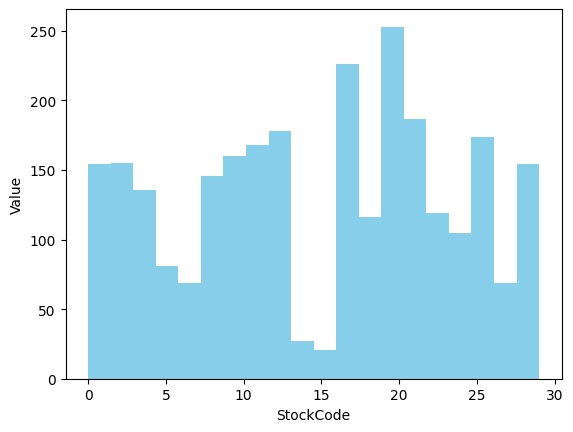

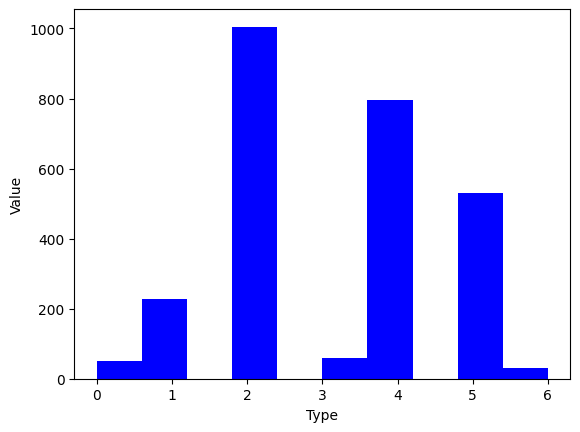

In [9]:
import matplotlib.pyplot as plt


plt.hist(df['StockCode'], bins=20, color='skyblue')
plt.xlabel('StockCode')
plt.ylabel('Value')
plt.show()
plt.hist(df['Type'], bins=10, color = 'blue')
plt.xlabel('Type')
plt.ylabel('Value')
plt.show()

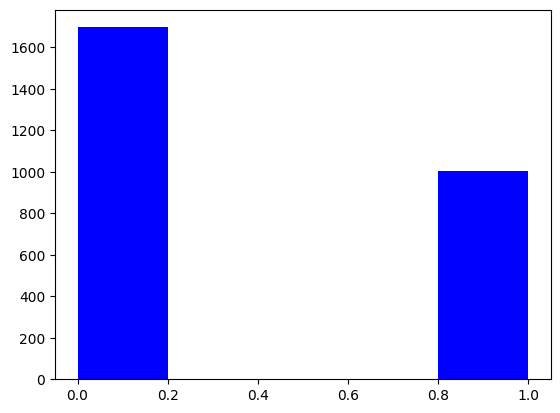

In [10]:
plt.hist(df['Target'], bins=5, color="blue")
plt.show()

In [11]:
df['Target'].value_counts()

Target
0    1696
1    1002
Name: count, dtype: int64

## PHOBERT

In [ ]:
import torch
from transformers import AutoModel, AutoTokenizer

list_model = [""]
phobert = AutoModel.from_pretrained("vinai/phobert-base-v2")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
phobert.to(device)
phobert.eval()

/data/chuanh/miniconda/envs/backend_fitness/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 17675.53it/s]
[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. C

RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(64001, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(258, 768, padding_idx=1)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropou

In [14]:
import py_vncorenlp

# Automatically download VnCoreNLP components from the original repository
# and save them in some local machine folder
py_vncorenlp.download_model(save_dir='/home/chuanh/quanlm/CoreNLP')

VnCoreNLP model folder /home/chuanh/quanlm/CoreNLP already exists! Please load VnCoreNLP from this folder!


In [15]:
import py_vncorenlp

model = py_vncorenlp.VnCoreNLP(
    annotators=["wseg"],
    save_dir='/home/chuanh/quanlm/CoreNLP'
)

2026-05-05 13:35:15 INFO  WordSegmenter:24 - Loading Word Segmentation model


In [16]:
df['Title'] = df['Title'].apply(lambda x : model.word_segment(x)[0])

In [17]:
# with torch.no_grad():
#     texts = df['Title'].to_list()
#     embeddings = []
#     for i in range(0, len(texts),32):
#         batch_text = texts[i:i+32]
#         text_token = tokenizer(batch_text, padding=True, truncation=True, return_tensors='pt')
        
#         encoded_input = {k: v.to(device) for k, v in text_token.items()}

#         model_output = phobert(**encoded_input)

#         # Lấy vector của token [CLS]
#         batch_embeddings = model_output.last_hidden_state[:, 0, :].cpu().numpy()
#         embeddings.append(batch_embeddings)
    

In [18]:
import torch
import numpy as np

with torch.no_grad():
    texts = df['Title'].to_list()
    embeddings = []
    
    for i in range(0, len(texts), 32):
        batch_text = texts[i:i+32]
        text_token = tokenizer(batch_text, padding=True, truncation=True, return_tensors='pt')
        
        encoded_input = {k: v.to(device) for k, v in text_token.items()}

        model_output = phobert(**encoded_input)

        # 1. Lấy toàn bộ vector của tất cả các token: kích thước [batch_size, seq_len, 768]
        token_embeddings = model_output.last_hidden_state
        
        # 2. Lấy attention_mask để biết token nào là chữ thật (1), token nào là [PAD] (0)
        attention_mask = encoded_input['attention_mask']
        
        # 3. Mở rộng chiều của mask cho khớp với token_embeddings: [batch_size, seq_len, 768]
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        
        # 4. Nhân vector với mask (để triệt tiêu vector của từ PAD về 0) và tính tổng theo chiều dọc (chiều từ/câu)
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
        
        # 5. Tính số lượng từ thật sự trong mỗi câu (dùng clamp để tránh lỗi chia cho 0)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        
        # 6. Chia trung bình tổng vector cho số lượng từ thật
        mean_pooled_embeddings = sum_embeddings / sum_mask

        # Chuyển về numpy và đưa vào list
        batch_embeddings = mean_pooled_embeddings.cpu().numpy()
        embeddings.append(batch_embeddings)

## DataPreprocessing

In [19]:
embeddings = np.vstack(embeddings)
stock_ids = df["StockCode"].values 
type_ids = df["Type"].values     
labels = df["Target"].values 

In [20]:
print(embeddings.shape)
print(stock_ids.shape)
print(type_ids.shape)
print(labels.shape)

(2698, 768)
(2698,)
(2698,)
(2698,)


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedKFold
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = df.sort_values("date").reset_index(drop=True)
n_samples = len(df)

#train dataset
train_size = int(n_samples * 0.9)

Y = df["Target"]
X = df.drop(["Target"], axis = 1)

X_train = X[:train_size + 1]
Y_train = Y[:train_size + 1]

X_test = 

# X_text_train = embeddings[:train_size + 1]
# X_stock_train = stock_ids[:train_size + 1]
# X_type_train = type_ids[:train_size+ 1]
# Y_train = labels[:train_size+ 1]

# #test dataset
# X_text_test = embeddings[train_size:]
# X_stock_test = stock_ids[train_size:]
# X_type_test = type_ids[train_size:]
# Y_test = labels[train_size:]


# print("Samples Train: ", len(Y_train))
# print("Samples Test: ", len(Y_test))

Samples Train:  2429
Samples Test:  270


In [22]:
from torch.utils.data import Dataset, DataLoader

class StockDataset(Dataset):
    def __init__(self, X_text, X_stock, X_type, y):
        self.X_text = torch.tensor(X_text, dtype=torch.float32)
        self.X_stock = torch.tensor(X_stock, dtype=torch.long)
        self.X_type = torch.tensor(X_type, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.X_text[idx],
            self.X_stock[idx],
            self.X_type[idx],
            self.y[idx]
        )

## Model

In [23]:
# class ProjectionMLP(nn.Module):
#     def __init__(self, phobert_dim, num_stocks, num_types, proj_dim, hidden_size):
#         super().__init__()
        
#         self.phobert_proj = nn.Linear(phobert_dim, proj_dim)
#         self.stock_embedding = nn.Embedding(num_stocks, proj_dim // 2)
#         self.type_embedding = nn.Embedding(num_types, proj_dim // 2)
        
#         combined_dim = proj_dim + (proj_dim // 2) + (proj_dim // 2)
        
#         self.fc1 = nn.Linear(combined_dim, hidden_size)
#         self.relu = nn.ReLU()
#         self.dropout = nn.Dropout(0.3)
#         self.fc2 = nn.Linear(hidden_size, 1)

#     def forward(self, x_text, x_stock, x_type):
#         x_text = self.relu(self.phobert_proj(x_text))
#         x_stock = self.stock_embedding(x_stock)
#         x_type = self.type_embedding(x_type)

#         x = torch.cat((x_text, x_stock, x_type), dim=1)
#         x = self.fc1(x)
#         x = self.relu(x)
#         x = self.dropout(x)
#         x = self.fc2(x)
#         return x 

In [24]:
class ProjectionMLP(nn.Module):
    def __init__(self, phobert_dim, num_stocks, num_types, proj_dim, hidden_size):
        super().__init__()
        
        # 1. Nhánh Text: Thêm LayerNorm
        # LayerNorm giúp đưa các giá trị vector text (vốn rất lớn từ PhoBERT) 
        # về cùng một thang đo ổn định, tránh "đè bẹp" các embedding nhỏ khác.
        self.phobert_proj = nn.Sequential(
            nn.Linear(phobert_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.ReLU()
        )
        
        # 2. Nhánh Categorical Embeddings
        self.stock_embedding = nn.Embedding(num_stocks, proj_dim // 2)
        self.type_embedding = nn.Embedding(num_types, proj_dim // 2)
        
        # 3. Nhánh Phân loại (MLP): Thêm BatchNorm1d
        # BatchNorm1d cực kỳ hiệu quả với dữ liệu tabular/ít dữ liệu. 
        # Nó giúp gradient đi xuống mượt hơn, hội tụ nhanh hơn và đóng vai trò như 1 bộ Regularization.
        combined_dim = proj_dim + (proj_dim // 2) + (proj_dim // 2)
        
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_size),
            nn.BatchNorm1d(hidden_size),  # Thêm BatchNorm TRƯỚC hàm kích hoạt
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x_text, x_stock, x_type):
        # Biến đổi đặc trưng
        x_text = self.phobert_proj(x_text)
        x_stock = self.stock_embedding(x_stock)
        x_type = self.type_embedding(x_type)

        # Ghép nối (Fusion)
        x_combined = torch.cat((x_text, x_stock, x_type), dim=1)
        
        # Dự đoán
        logits = self.classifier(x_combined)
        return logits

## Training

In [25]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [26]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for x_text, x_stock, x_type, y in loader:
        x_text = x_text.to(device)
        x_stock = x_stock.to(device)
        x_type = x_type.to(device)
        y = y.to(device).unsqueeze(1)

        optimizer.zero_grad()
        logits = model(x_text, x_stock, x_type)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss

In [27]:
def evaluate(model, loader, criterion = nn.BCEWithLogitsLoss(), device = "cpu"):
    model.eval()
    
    total_loss = 0
    preds, labels = [], []

    with torch.no_grad():
        for x_text, x_stock, x_type, y in loader:
            x_text = x_text.to(device)
            x_stock = x_stock.to(device)
            x_type = x_type.to(device)
            y = y.to(device).unsqueeze(1)

            logits = model(x_text, x_stock, x_type)
            loss = criterion(logits, y)
            total_loss += loss.item()

            probs = torch.sigmoid(logits)
            pred = (probs > 0.5).int().cpu().numpy()

            preds.extend(pred.flatten())
            labels.extend(y.cpu().numpy().flatten())

    acc = accuracy_score(labels, preds)
    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    f1 = f1_score(labels, preds)

    return total_loss, acc, precision, recall, f1

In [28]:
print(type(num_stocks), num_stocks)
print(type(num_types), num_types)

<class 'int'> 30
<class 'int'> 7


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_logs = []  
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_text_train, y_train)):
    print(f"\n===== Fold {fold} =====")

    train_dataset = StockDataset(
        X_text_train[train_idx],
        X_stock_train[train_idx],
        X_type_train[train_idx],
        Y_rain[train_idx]
    )

    val_dataset = StockDataset(
        X_text_train[val_idx],
        X_stock_train[val_idx],
        X_type_train[val_idx],
        Y_train[val_idx]
    )

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)

    model = ProjectionMLP(
        phobert_dim=768,
        num_stocks=num_stocks,
        num_types=num_types,
        proj_dim=256,
        hidden_size=128
    ).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-4
    )
    criterion = nn.BCEWithLogitsLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )
    epochs = 30

    for epoch in range(epochs):
        #train
        train_loss = train(model, train_loader, optimizer, criterion, device)
        #val
        val_loss, acc, precision, recall, f1 = evaluate(
            model, val_loader, criterion, device
        )
        scheduler.step(val_loss)
        #result
        print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {acc:.4f}")

        # lưu log
        all_logs.append({
            "fold": fold,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    fold_scores.append(acc)

print("CV Mean Accuracy:", np.mean(fold_scores))


===== Fold 0 =====


Epoch 1 | Train Loss: 37.0520 | Val Loss: 8.9399 | Acc: 0.7366
Epoch 2 | Train Loss: 29.3364 | Val Loss: 7.7527 | Acc: 0.7593
Epoch 3 | Train Loss: 25.2654 | Val Loss: 7.2928 | Acc: 0.7901
Epoch 4 | Train Loss: 21.9931 | Val Loss: 6.6974 | Acc: 0.8251
Epoch 5 | Train Loss: 19.1327 | Val Loss: 6.4373 | Acc: 0.8086
Epoch 6 | Train Loss: 17.5345 | Val Loss: 6.0334 | Acc: 0.8272
Epoch 7 | Train Loss: 15.6209 | Val Loss: 5.8820 | Acc: 0.8416
Epoch 8 | Train Loss: 14.3430 | Val Loss: 5.9398 | Acc: 0.8272
Epoch 9 | Train Loss: 12.6561 | Val Loss: 5.7294 | Acc: 0.8354
Epoch 10 | Train Loss: 11.1460 | Val Loss: 5.7031 | Acc: 0.8333
Epoch 11 | Train Loss: 10.2052 | Val Loss: 5.5174 | Acc: 0.8436
Epoch 12 | Train Loss: 9.3194 | Val Loss: 5.5596 | Acc: 0.8498
Epoch 13 | Train Loss: 8.4778 | Val Loss: 5.4718 | Acc: 0.8642
Epoch 14 | Train Loss: 8.0997 | Val Loss: 5.6353 | Acc: 0.8601
Epoch 15 | Train Loss: 7.3591 | Val Loss: 5.2927 | Acc: 0.8704
Epoch 16 | Train Loss: 6.3309 | Val Loss: 5.6081 | Ac

## Visual Result

In [30]:
df_logs = pd.DataFrame(all_logs)

df_logs.to_excel("training_logs.xlsx", index=False)

print("Saved training_logs.xlsx")

Saved training_logs.xlsx


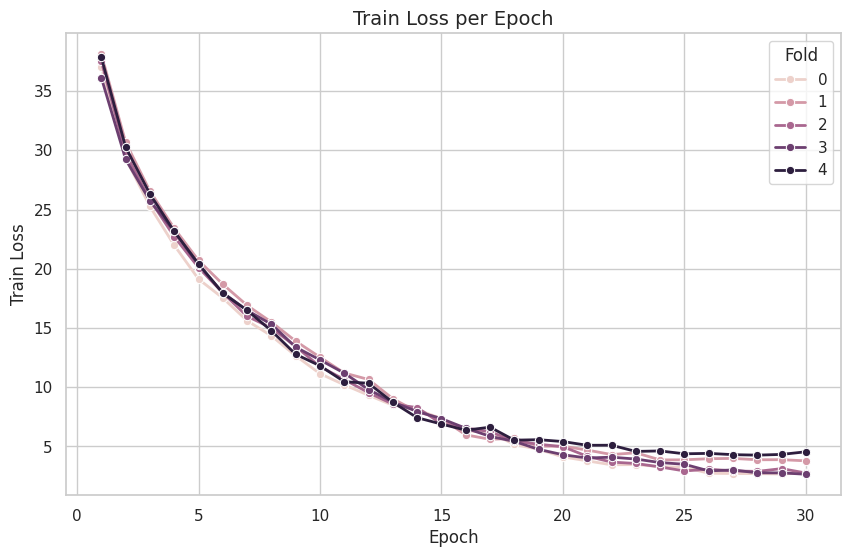

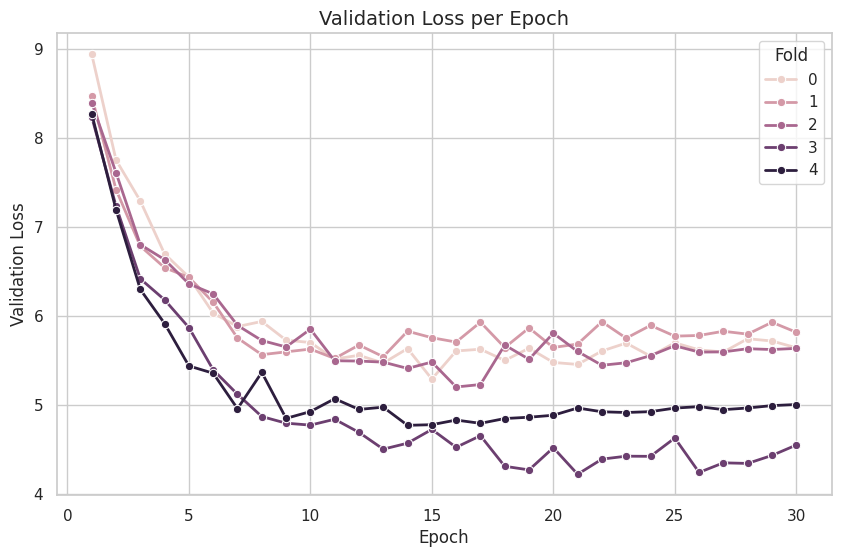

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style đẹp hơn
sns.set(style="whitegrid")

# =========================
# 1. Biểu đồ Train Loss riêng
# =========================
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_logs,
    x="epoch",
    y="train_loss",
    hue="fold",
    marker="o",
    linewidth=2
)

plt.title("Train Loss per Epoch", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.legend(title="Fold")
plt.show()


# =========================
# 2. Biểu đồ Validation Loss riêng
# =========================
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_logs,
    x="epoch",
    y="val_loss",
    hue="fold",
    marker="o",
    linewidth=2
)

plt.title("Validation Loss per Epoch", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend(title="Fold")
plt.show()

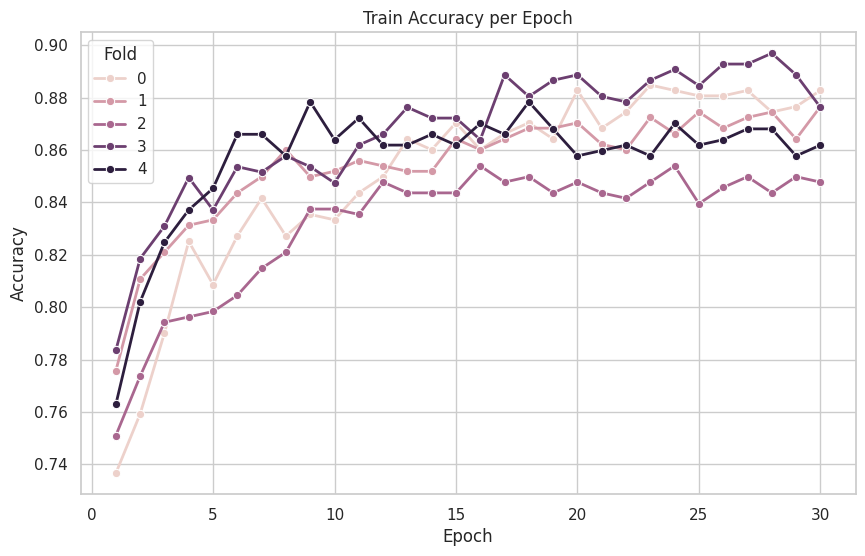

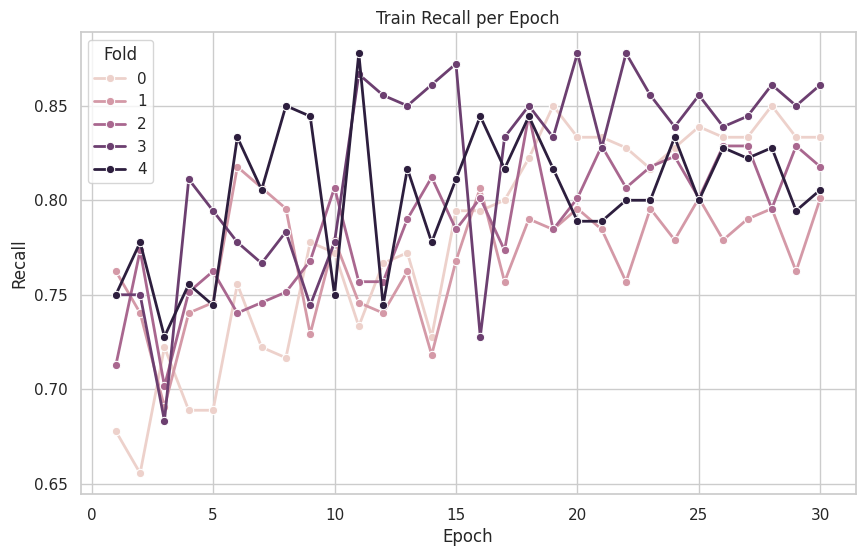

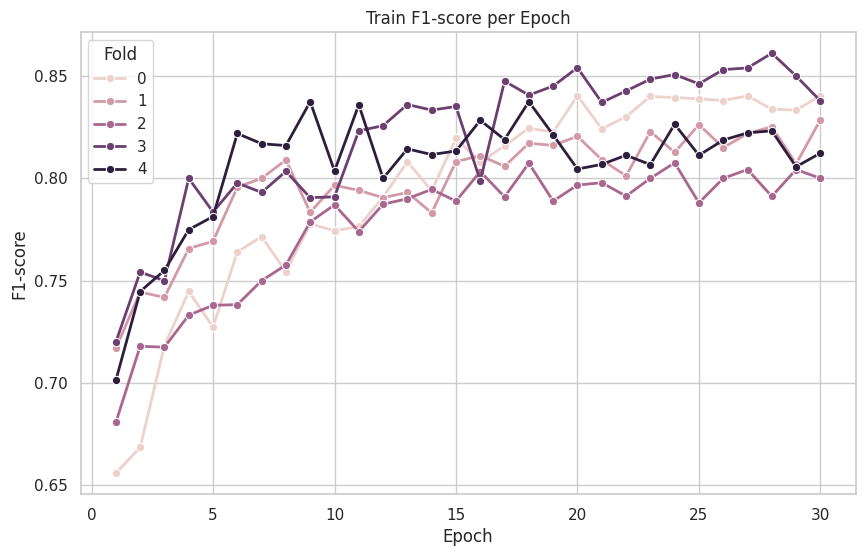

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ==================================================
# TRAIN METRICS
# ==================================================

# 1. Train Accuracy
plt.figure(figsize=(10,6))
sns.lineplot(data=df_logs, x="epoch", y="accuracy", hue="fold", marker="o", linewidth=2)
plt.title("Train Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(title="Fold")
plt.show()

# 2. Train Recall
plt.figure(figsize=(10,6))
sns.lineplot(data=df_logs, x="epoch", y="recall", hue="fold", marker="o", linewidth=2)
plt.title("Train Recall per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend(title="Fold")
plt.show()

# 3. Train F1-score
plt.figure(figsize=(10,6))
sns.lineplot(data=df_logs, x="epoch", y="f1", hue="fold", marker="o", linewidth=2)
plt.title("Train F1-score per Epoch")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend(title="Fold")
plt.show()

In [33]:
df_fold_summary = df_logs.groupby("fold").agg({
    "accuracy": "max",
    "precision": "max",
    "recall": "max",
    "f1": "max"
}).reset_index()

print(df_fold_summary)

   fold  accuracy  precision    recall        f1
0     0  0.884774   0.873333  0.850000  0.840336
1     1  0.876543   0.861635  0.817680  0.828571
2     2  0.853909   0.820359  0.845304  0.807588
3     3  0.896907   0.885135  0.877778  0.861111
4     4  0.878351   0.865385  0.877778  0.837466


In [34]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_dataset = StockDataset(
    X_text_test,
    X_stock_test,
    X_type_test,
    y_test
)

test_loader = DataLoader(test_dataset, batch_size=32)
criterion = nn.BCEWithLogitsLoss()
test_results = evaluate(model, test_loader, criterion, device)
print(f"Final Test: \nTotal_Loss: {test_results[0]}\nAcc: {test_results[1]}\nPrecision: {test_results[2]}\nRecall: {test_results[3]}\nF1: {test_results[4]}")

Final Test: 
Total_Loss: 2.4252376332879066
Acc: 0.8740740740740741
Precision: 0.851063829787234
Recall: 0.8
F1: 0.8247422680412371
